In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,f1_score,roc_curve,confusion_matrix,auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic

import lightgbm as lgb

In [31]:
data=pd.read_csv(r"C:\Users\Acer\Downloads\dataset (1).csv")
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
data.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
print(data["merchant"].nunique())
print(data["category"].nunique())
print(data["gender"].nunique())
print(data["category"].unique())

693
14
2
['misc_net' 'grocery_pos' 'entertainment' 'gas_transport' 'misc_pos'
 'grocery_net' 'shopping_net' 'shopping_pos' 'food_dining' 'personal_care'
 'health_fitness' 'travel' 'kids_pets' 'home']


In [7]:
cat_col=["merchant","category","gender"]

encoders={}
for i in cat_col:
    le=LabelEncoder()
    data[i]=le.fit_transform(data[i])
    encoders[i]=le
    encoders

encoders

{'merchant': LabelEncoder(),
 'category': LabelEncoder(),
 'gender': LabelEncoder()}

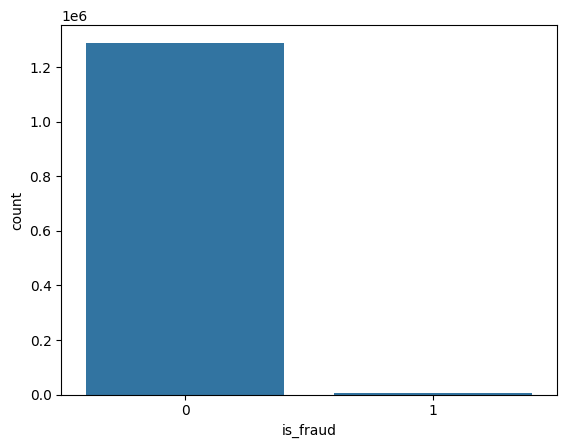

In [9]:
sns.countplot(data=data,x="is_fraud")
plt.show()

In [10]:
def harversine(lat1,lon1,lat2,lon2):
    return np.array([geodesic((a,b),(c,d)).km for a,b,c,d in zip(lat1,lon1,lat2,lon2)])# 

data["distance"]=harversine(data["lat"],data["long"],data["merch_lat"],data["merch_long"])

In [11]:
data.drop(columns=['first', 'last','street', 'city', 'state','job', 'dob', 'trans_num','trans_date_trans_time','Unnamed: 0','lat','long','merch_lat','merch_long','city_pop',"unix_time"],inplace=True)

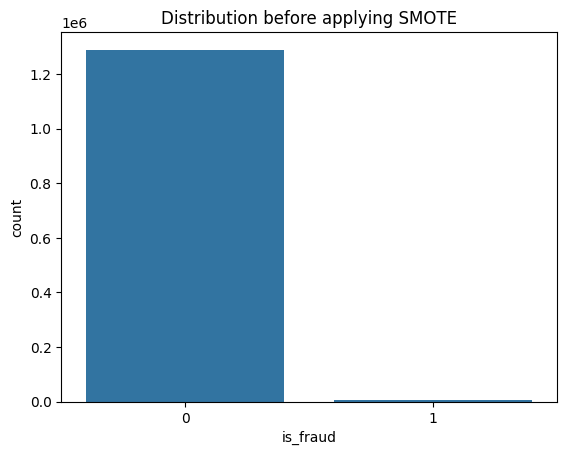

In [12]:
sns.countplot(data=data,x="is_fraud")
plt.title("Distribution before applying SMOTE")
plt.show()

In [13]:
x=data.drop(columns=["is_fraud"])
y=data["is_fraud"]

In [14]:
smote=SMOTE(random_state=42)
x_resample,y_resample=smote.fit_resample(x,y)

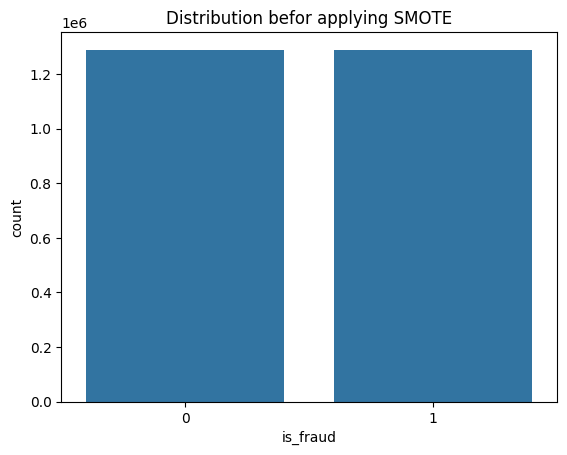

In [15]:
sns.countplot(data=data,x=y_resample)# Smote is use to balance the data
plt.title("Distribution befor applying SMOTE")
plt.show()

In [17]:
data.head()

,cc_num,merchant,category,amt,gender,zip,is_fraud,distance
0,2703186189652095,514,8,4.97,0,28654,0,78.773821
1,630423337322,241,4,107.23,0,99160,0,30.216618
2,38859492057661,390,0,220.11,1,83252,0,108.102912
3,3534093764340240,360,2,45.00,1,59632,0,95.685115
4,375534208663984,297,9,41.96,1,24433,0,77.702395


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x_resample,y_resample,test_size=0.2,random_state=42)


In [19]:
lgbm = lgb.LGBMClassifier(
    boosting_type="gbdt",
    objective="binary",
    metric="auc",
    is_unbalance=True,
    learning_rate=0.05,
    num_leaves=15,
    n_estimators=300,
    max_depth=1
)
lgbm.fit(x_train, y_train)


[LightGBM] [Info] Number of positive: 1030687, number of negative: 1031983
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1290
[LightGBM] [Info] Number of data points in the train set: 2062670, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499686 -> initscore=-0.001257
[LightGBM] [Info] Start training from score -0.001257
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=1, metric='auc',
               n_estimators=300, num_leaves=15, objective='binary')

In [20]:
y_pred=lgbm.predict(x_test)

In [21]:
print("Classification report\n", classification_report(y_test, y_pred))

Classification report
               precision    recall  f1-score   support

           0       0.82      0.95      0.88    257186
           1       0.94      0.79      0.86    258482

    accuracy                           0.87    515668
   macro avg       0.88      0.87      0.87    515668
weighted avg       0.88      0.87      0.87    515668



<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

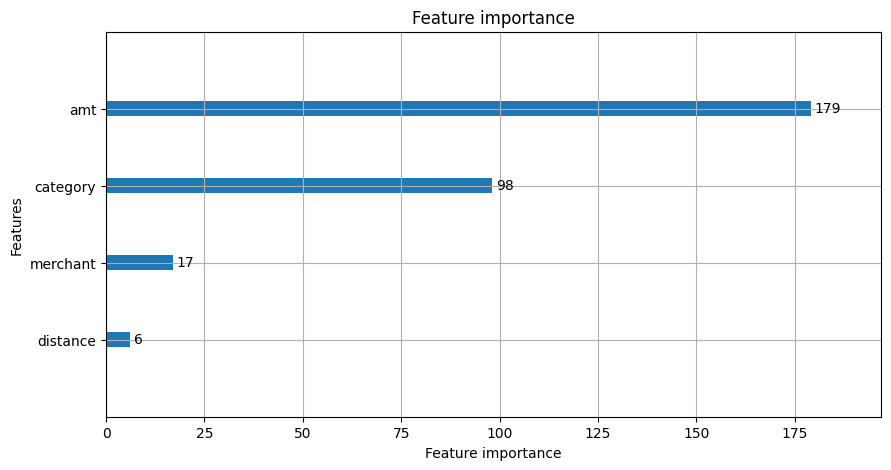

In [22]:
lgb.plot_importance(lgbm, max_num_features=10, importance_type="split", figsize=(10,5))

In [23]:
print("AUC-ROC:", roc_auc_score(y_test, y_pred))
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred))

AUC-ROC: 0.8721194371104808
Confusion Matrix
 [[244357  12829]
 [ 53216 205266]]


In [24]:
fpr,tpr,thress=roc_curve(y_test,lgbm.predict_proba(x_test)[:,1])
roc_auc=(auc(fpr,tpr)*100)

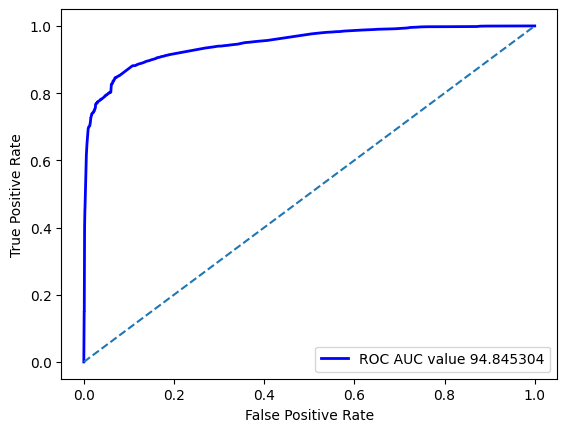

In [25]:
plt.plot(fpr,tpr,color="blue",lw=2,label=f"ROC AUC value {roc_auc:2f}")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [26]:
import pickle as pkl

with open("credit_card_fraud.pkl","wb") as f:
    pkl.dump(lgbm,f)

with open("label_encoder.pkl","wb") as f:
    pkl.dump(encoders,f)